## Use the data from the file, read it into a dataframe, and make any modifications you find useful to solve the task.
The fig size is still the same; you can choose whatever font size you like.
The color palette should be the same as in the example.
The font size of the title is 15.
The width of the box lines is 3 and the width of the median lines is 2.
At the end of your Jupyter Notebook, create a Markdown cell and insert the following question: "What was the IQR of the control group before the newsfeed?" In your answer, provide an approximate value that can be obtained simply by looking at the graph and round it to the nearest 10.


/var/folders/4_/1583ffcn4xs28f1l_3txy30w0000gn/T/ipykernel_55615/1164526118.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/4_/1583ffcn4xs28f1l_3txy30w0000gn/T/ipykernel_55615/1164526118.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


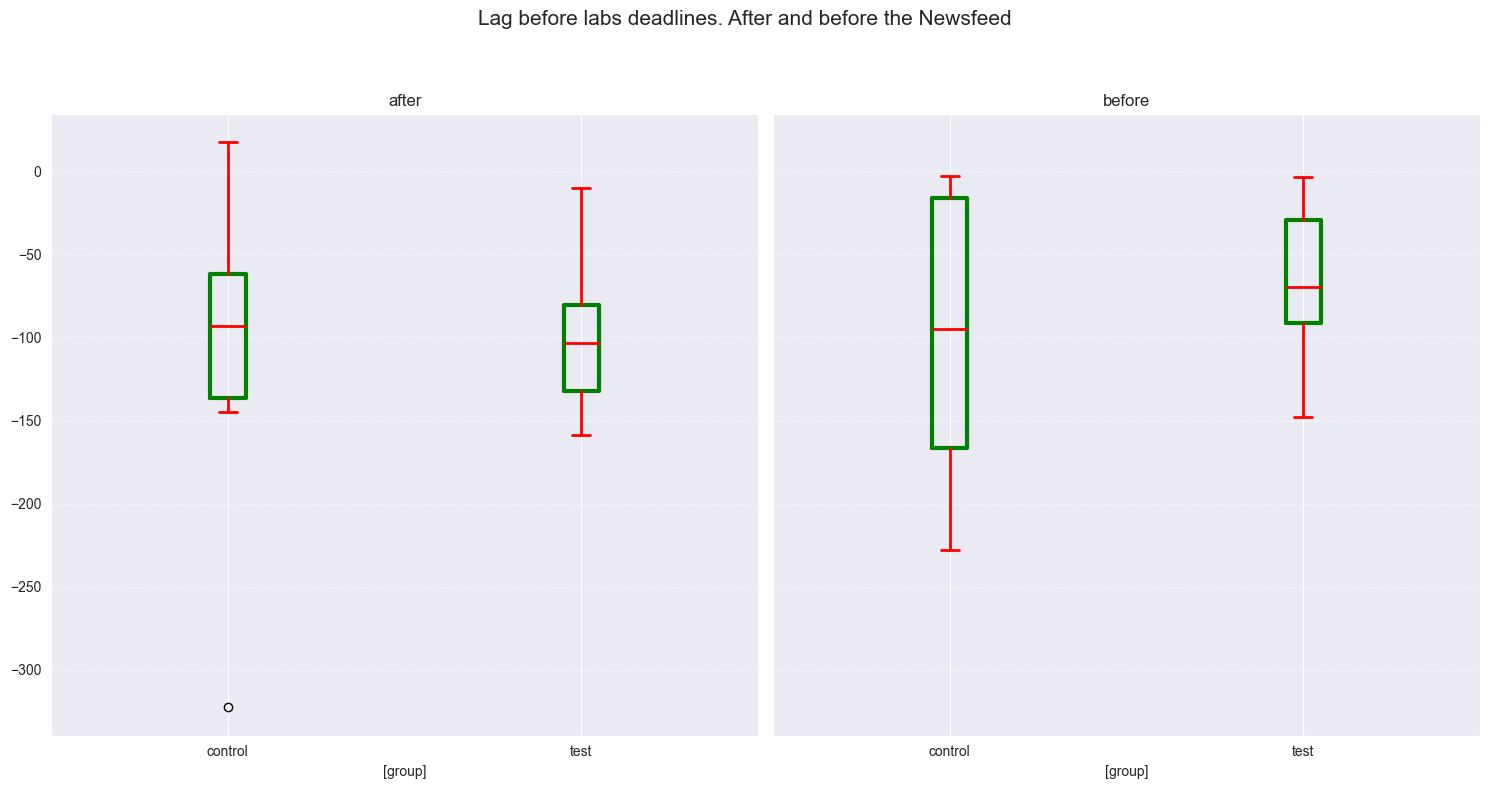

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('../data/ab-test.csv')
test = df.loc[df['group'] == 'test', "diff"]
control = df.loc[df['group'] == 'control', 'diff']
groups_order = ['control', 'test']

fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharey=True)

fig.suptitle(
    'Lag before labs deadlines. After and before the Newsfeed',
    fontsize=15
)

boxprops     = dict(color='green', linewidth=3)   
whiskerprops = dict(color='red',   linewidth=2)   
capprops     = dict(color='red',   linewidth=2)   
medianprops  = dict(color='red', linewidth=2)   

ax = axes[0]
data_after = [
    df[(df['time'] == 'after') & (df['group'] == g)]['diff'].dropna()
    for g in groups_order
]

ax.boxplot(
    data_after,
    labels=groups_order,
    boxprops=boxprops,
    whiskerprops=whiskerprops,
    capprops=capprops,
    medianprops=medianprops,
    widths=0.1
)
ax.set_title('after')
ax.set_xlabel('[group]')
ax.grid(axis='y', linestyle='--', alpha=0.5)

ax = axes[1]
data_before = [
    df[(df['time'] == 'before') & (df['group'] == g)]['diff'].dropna()
    for g in groups_order
]

ax.boxplot(
    data_before,
    labels=groups_order,
    boxprops=boxprops,
    whiskerprops=whiskerprops,
    capprops=capprops,
    medianprops=medianprops,
    widths=0.1
)
ax.set_title('before')
ax.set_xlabel('[group]')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()


## Каков был межквартильный размах (IQR) контрольной группы до появления новостной ленты?

Ответ: -20-(-170) =150